In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_auc_score,
                             roc_curve)
import pickle
import warnings
warnings.filterwarnings('ignore')

In [37]:
print("Libraries loaded successfully!")

Libraries loaded successfully!


In [38]:
# %% ── 2. Load Dataset
# Download from: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
# Place diabetes.csv in the data_samples/ folder
try:
    df = pd.read_csv("C:/Users/Admin/Desktop/diabetes new.csv")
    print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
except FileNotFoundError:
    # Generate synthetic data for demonstration
    np.random.seed(42)
    n = 768
    df = pd.DataFrame({
        'Pregnancies':       np.random.randint(0, 17, n),
        'Glucose':           np.random.randint(44, 200, n),
        'BloodPressure':     np.random.randint(24, 122, n),
        'SkinThickness':     np.random.randint(0, 100, n),
        'Insulin':           np.random.randint(0, 846, n),
        'BMI':               np.round(np.random.uniform(0, 67.1, n), 1),
        'DiabetesPedigreeFunction': np.round(np.random.uniform(0.078, 2.42, n), 3),
        'Age':               np.random.randint(21, 81, n),
        'Outcome':           np.random.randint(0, 2, n)
    })
    print("Using synthetic dataset for demo")


Dataset loaded: 768 rows, 9 columns


In [39]:
# %% ── 3. Exploratory Data Analysis
print("\n=== Dataset Info ===")
print(df.head())
print(f"\nShape: {df.shape}")
print(f"\nNull values:\n{df.isnull().sum()}")
print(f"\nOutcome distribution:\n{df['Outcome'].value_counts()}")
print(f"\nStatistics:\n{df.describe()}")



=== Dataset Info ===
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Shape: (768, 9)

Null values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome   

Text(0.5, 0.98, 'Diabetes Dataset - EDA')

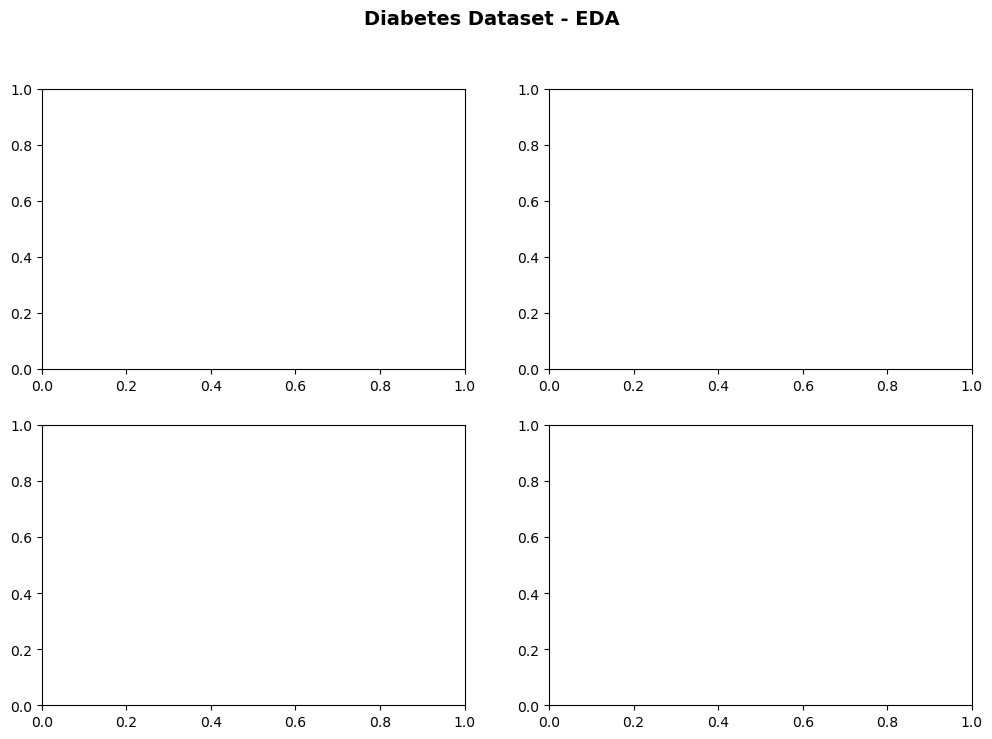

In [40]:
# %% ── 4. Visualizations
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Diabetes Dataset - EDA', fontsize=14, fontweight='bold')


In [41]:
# Distribution of outcome
axes[0, 0].pie(df['Outcome'].value_counts(),
               labels=['Non-Diabetic', 'Diabetic'],
               autopct='%1.1f%%', colors=['#4CAF50', '#F44336'])
axes[0, 0].set_title('Outcome Distribution')

Text(0.5, 1.0, 'Outcome Distribution')

In [42]:
# Glucose vs Outcome
df.groupby('Outcome')['Glucose'].plot(kind='hist', ax=axes[0, 1],
                                       alpha=0.6, legend=True)
axes[0, 1].set_title('Glucose by Outcome')
axes[0, 1].set_xlabel('Glucose')
axes[0, 1].legend(['Non-Diabetic', 'Diabetic'])


In [43]:
# Correlation heatmap
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1, 0], cbar=True, square=True, annot_kws={"size": 7})
axes[1, 0].set_title('Feature Correlation')


Text(0.5, 1.0, 'Feature Correlation')

In [44]:
# Age distribution
df[df['Outcome'] == 0]['Age'].plot(kind='hist', ax=axes[1, 1],
                                    alpha=0.6, color='green', label='Non-Diabetic')
df[df['Outcome'] == 1]['Age'].plot(kind='hist', ax=axes[1, 1],
                                    alpha=0.6, color='red', label='Diabetic')
axes[1, 1].set_title('Age Distribution by Outcome')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('C:/Users/Admin/Desktop/diabetes_new.png', dpi=100, bbox_inches='tight')
plt.show()
print("EDA plots saved!")

<Figure size 640x480 with 0 Axes>

EDA plots saved!


In [45]:

# %% ── 5. Data Preprocessing
# Replace zero values in medical features with median (zeros are invalid)
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_cols:
    df[col] = df[col].replace(0, df[col].median())


In [46]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']


In [47]:
# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


In [48]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (614, 8), Test: (154, 8)


In [49]:
# %% ── 6. Model Training
model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
model.fit(X_train_scaled, y_train)
print("Model trained!")


Model trained!


In [50]:
# %% ── 7. Model Evaluation
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [51]:
train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
test_acc  = accuracy_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_prob)

In [52]:
print(f"\n{'='*40}")
print(f"  Training Accuracy : {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"  Test  Accuracy    : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"  ROC-AUC Score     : {roc_auc:.4f}")
print(f"{'='*40}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred, target_names=['Non-Diabetic','Diabetic'])}")


  Training Accuracy : 0.8453 (84.53%)
  Test  Accuracy    : 0.7338 (73.38%)
  ROC-AUC Score     : 0.7939

Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.77      0.84      0.80       100
    Diabetic       0.64      0.54      0.59        54

    accuracy                           0.73       154
   macro avg       0.71      0.69      0.69       154
weighted avg       0.73      0.73      0.73       154



Text(0.5, 14.722222222222216, 'Predicted')

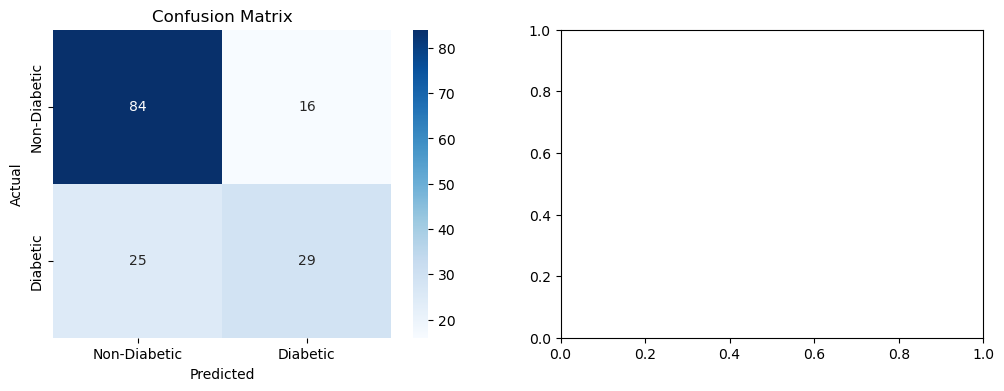

In [53]:
# Confusion Matrix Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Non-Diabetic','Diabetic'],
            yticklabels=['Non-Diabetic','Diabetic'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')


In [54]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
axes[1].plot([0,1], [0,1], color='navy', linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
plt.tight_layout()
plt.savefig('C:/Users/Admin/Desktop/diabetes_eval.png', dpi=100, bbox_inches='tight')
plt.show()


<Figure size 640x480 with 0 Axes>

In [55]:
# %% ── 8. Save Model & Scaler
with open('C:/Users/Admin/Desktop/diabetes_model.pkl', 'wb') as f:
    pickle.dump(model, f)
with open('C:/Users/Admin/Desktop/diabetes_model.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("\nModel and scaler saved to models/ directory!")


Model and scaler saved to models/ directory!


In [56]:
# %% ── 9. Sample Prediction
print("\n=== Sample Prediction ===")
sample = np.array([[6, 148, 72, 35, 0, 33.6, 0.627, 50]])
sample_scaled = scaler.transform(sample)
prediction = model.predict(sample_scaled)
probability = model.predict_proba(sample_scaled)[0]
print(f"Input: Pregnancies=6, Glucose=148, BP=72, Skin=35, Insulin=0, BMI=33.6, DPF=0.627, Age=50")
print(f"Prediction: {'Diabetic' if prediction[0] == 1 else 'Non-Diabetic'}")
print(f"Confidence: Non-Diabetic={probability[0]:.3f}, Diabetic={probability[1]:.3f}")


=== Sample Prediction ===
Input: Pregnancies=6, Glucose=148, BP=72, Skin=35, Insulin=0, BMI=33.6, DPF=0.627, Age=50
Prediction: Diabetic
Confidence: Non-Diabetic=0.218, Diabetic=0.782
